# Credit Card Fraud Detection
## Phase 6: XGBoost Baseline

In this phase, we train a supervised XGBoost classifier to serve as a benchmark against the unsupervised Autoencoder. We handle the severe class imbalance by tuning `scale_pos_weight`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sys

# Add src to path
sys.path.append('../')
from src.preprocessing import split_data_anomaly_detection, preprocess_features, load_config
from src.xgboost_model import train_xgboost, evaluate_xgboost

# Load config
config = load_config('../configs/config.yaml')


### 1. Load Data
We load the exact same subset and use the exact same splits to ensure a fair comparison. Note that for XGBoost, we *can* use the fraud labels during training, but to keep the splits strictly identical to the Autoencoder, the training set currently has 0 fraud instances!

Wait, if the training set has 0 fraud instances, XGBoost cannot learn the fraud class. So for supervised training, we need to create a supervised split of the data.

In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../' + config['data']['subset_path'])

# For XGBoost, we do a standard stratified split to include fraud in training
X_full = df.drop('Class', axis=1)
y_full = df['Class']

# Same random state and test size, but stratified
X_temp, X_test_xgb, y_temp, y_test_xgb = train_test_split(
    X_full, y_full, test_size=config['data']['test_size'], stratify=y_full, random_state=config['random_seed']
)

relative_val_size = config['data']['val_size'] / (1.0 - config['data']['test_size'])
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_temp, y_temp, test_size=relative_val_size, stratify=y_temp, random_state=config['random_seed']
)

print(f"XGB Train Fraud: {y_train_xgb.sum()} / {len(y_train_xgb)}")
print(f"XGB Val Fraud: {y_val_xgb.sum()} / {len(y_val_xgb)}")
print(f"XGB Test Fraud: {y_test_xgb.sum()} / {len(y_test_xgb)}")

# Scale Amount and Time based on XGB Train
from sklearn.preprocessing import RobustScaler
scaler_amount_xgb = RobustScaler()
scaler_time_xgb = RobustScaler()

X_train_xgb_scaled = X_train_xgb.copy()
X_val_xgb_scaled = X_val_xgb.copy()
X_test_xgb_scaled = X_test_xgb.copy()

X_train_xgb_scaled['Amount_scaled'] = scaler_amount_xgb.fit_transform(X_train_xgb[['Amount']])
X_train_xgb_scaled['Time_scaled'] = scaler_time_xgb.fit_transform(X_train_xgb[['Time']])
X_val_xgb_scaled['Amount_scaled'] = scaler_amount_xgb.transform(X_val_xgb[['Amount']])
X_val_xgb_scaled['Time_scaled'] = scaler_time_xgb.transform(X_val_xgb[['Time']])
X_test_xgb_scaled['Amount_scaled'] = scaler_amount_xgb.transform(X_test_xgb[['Amount']])
X_test_xgb_scaled['Time_scaled'] = scaler_time_xgb.transform(X_test_xgb[['Time']])

cols_to_drop = ['Amount', 'Time']
final_features = ['Time_scaled'] + [f'V{i}' for i in range(1, 29)] + ['Amount_scaled']

X_train_xgb_final = X_train_xgb_scaled[final_features].values
X_val_xgb_final = X_val_xgb_scaled[final_features].values
X_test_xgb_final = X_test_xgb_scaled[final_features].values


XGB Train Fraud: 295 / 18294
XGB Val Fraud: 99 / 6099
XGB Test Fraud: 98 / 6099


### 2. Train XGBoost Model
We use `scale_pos_weight` to address the severe class imbalance. We set it to the ratio of negative to positive classes in the training set.

In [3]:
# Calculate scale_pos_weight
neg_class = (y_train_xgb == 0).sum()
pos_class = (y_train_xgb == 1).sum()
scale_pos_weight = neg_class / pos_class
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")

model_xgb = train_xgboost(X_train_xgb_final, y_train_xgb, scale_pos_weight=scale_pos_weight)
print("XGBoost training complete.")


Using scale_pos_weight: 61.01


XGBoost training complete.


### 3. Evaluate on Validation Set

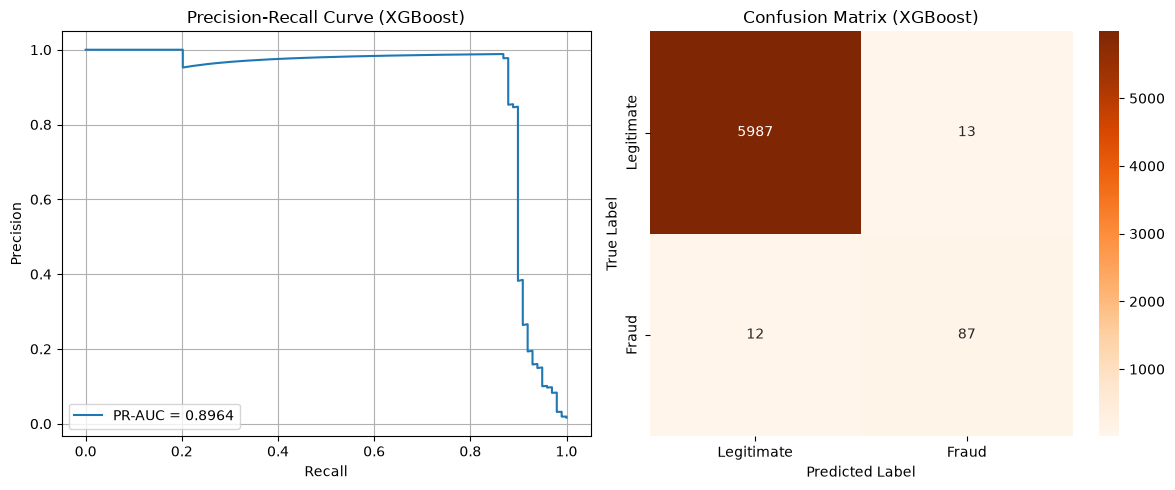

XGBoost Validation Metrics:
PR-AUC:    0.8964
ROC-AUC:   0.9785
F1-Score:  0.8744
Precision: 0.8700
Recall:    0.8788


In [4]:
metrics_xgb = evaluate_xgboost(model_xgb, X_val_xgb_final, y_val_xgb, plot=True)

print("XGBoost Validation Metrics:")
print(f"PR-AUC:    {metrics_xgb['pr_auc']:.4f}")
print(f"ROC-AUC:   {metrics_xgb['roc_auc']:.4f}")
print(f"F1-Score:  {metrics_xgb['f1']:.4f}")
print(f"Precision: {metrics_xgb['precision']:.4f}")
print(f"Recall:    {metrics_xgb['recall']:.4f}")


### 4. Save XGBoost Model

In [5]:
import joblib
joblib.dump(model_xgb, '../models/xgboost_baseline.pkl')
print("Model saved to models/xgboost_baseline.pkl")


Model saved to models/xgboost_baseline.pkl
